<a href="https://colab.research.google.com/github/Alamgir-JUST/Machine-Learning-Projects/blob/main/ANN_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gallstone prediction using ANN.**

In [1]:
import matplotlib.pyplot as plt
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [2]:
##Dataset Link: https://archive.ics.uci.edu/dataset/1150/gallstone-1

## **Dataset Connection**

In [3]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Machine Learning Lab/Gallstone.csv")

In [5]:
df

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


In [6]:
df.shape

(319, 39)

In [7]:
df['Gallstone Status'].value_counts()

,count
Gallstone Status,
0,161
1,158


## **Processing**

In [8]:
# -------------------------------
# Import required libraries
# -------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Display basic dataset information
# -------------------------------
print("===== Original Dataset Information =====")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
display(df.head())

# -------------------------------
# Define input features (X) and target variable (y)
# -------------------------------

# 'Gallstone Status' is the output column:
# 0 = No Gallstone
# 1 = Gallstone Present
X = df.drop('Gallstone Status', axis=1)
y = df['Gallstone Status']

print("\n===== Feature Matrix and Target Vector =====")
print("X shape (features):", X.shape)
print("y shape (target):", y.shape)

# -------------------------------
# Check class distribution
# -------------------------------
# This helps us understand whether the dataset is balanced.
print("\n===== Class Distribution =====")
print(y.value_counts())

# -------------------------------
# Check missing values
# -------------------------------
# Missing values must be handled before model training.
print("\n===== Missing Values in Each Column =====")
missing_values = df.isnull().sum()
print(missing_values)

# Show only columns with missing values, if any exist
missing_columns = missing_values[missing_values > 0]
if len(missing_columns) == 0:
    print("\nNo missing values found in the dataset.")
else:
    print("\nColumns with missing values:")
    print(missing_columns)

# -------------------------------
# Check data types
# -------------------------------
# ANN models require numeric input.
print("\n===== Data Types of All Columns =====")
print(df.dtypes)

# Identify non-numeric columns, if any
non_numeric_cols = X.select_dtypes(include=['object']).columns.tolist()

print("\n===== Non-Numeric Feature Columns =====")
if len(non_numeric_cols) == 0:
    print("All input features are numeric. No encoding is required.")
else:
    print("The following columns are non-numeric and may require encoding:")
    print(non_numeric_cols)

# -------------------------------
# Split data into training and testing sets
# -------------------------------
# We use stratify=y to preserve the same class ratio
# in both training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% test data, 80% training data
    random_state=42,     # ensures reproducibility
    stratify=y           # preserves class balance
)

print("\n===== Train-Test Split =====")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

# -------------------------------
# 8. Standardize the input features
# -------------------------------
# Standardization is important for ANN because the features
# may have different scales (e.g., Age, BMI, Glucose, etc.).

# StandardScaler transforms each feature using:
# z = (x - mean) / standard deviation

## Important:
# - fit_transform() is applied only on training data
# - transform() is applied on testing data
# This prevents data leakage.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# Convert scaled arrays back to DataFrames
# -------------------------------
# This step is optional, but it makes the scaled data easier
# to inspect because the column names are preserved.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# -------------------------------
# Display final processed data information
# -------------------------------
print("\n===== Scaled Data Information =====")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

print("\nFirst 5 rows of scaled training data:")
display(X_train_scaled.head())

print("\nFirst 5 target values of training data:")
display(y_train.head())

# -------------------------------
# Final note
# -------------------------------
print("===== Preprocessing Completed Successfully =====")
print("The dataset is now ready to be used in an ANN model.")
print("Available variables for the next step:")
print("- X_train_scaled")
print("- X_test_scaled")
print("- y_train")
print("- y_test")

===== Original Dataset Information =====
Dataset shape: (319, 39)

First 5 rows of the dataset:


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6



===== Feature Matrix and Target Vector =====
X shape (features): (319, 38)
y shape (target): (319,)

===== Class Distribution =====
Gallstone Status
0    161
1    158
Name: count, dtype: int64

===== Missing Values in Each Column =====
Gallstone Status                                  0
Age                                               0
Gender                                            0
Comorbidity                                       0
Coronary Artery Disease (CAD)                     0
Hypothyroidism                                    0
Hyperlipidemia                                    0
Diabetes Mellitus (DM)                            0
Height                                            0
Weight                                            0
Body Mass Index (BMI)                             0
Total Body Water (TBW)                            0
Extracellular Water (ECW)                         0
Intracellular Water (ICW)                         0
Extracellular Fluid/Total Body Wate

,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
241,0.957108,1.003929,-0.668013,-0.179969,-0.191273,-0.15523,-0.398862,-1.114167,-0.681433,-0.003608,...,0.129898,-0.174385,-0.674547,-0.590697,0.663360,-0.874567,0.025359,1.021993,-2.057443,-1.259739
66,-1.146880,-0.996086,1.312723,-0.179969,-0.191273,-0.15523,-0.398862,0.455516,1.896882,1.505060,...,-0.401532,0.356744,1.123462,2.079301,0.953821,-0.706148,1.476409,-0.276084,0.610824,-1.348631
230,0.228805,-0.996086,1.312723,-0.179969,-0.191273,-0.15523,2.507133,-0.231220,-0.798925,-0.684348,...,-0.932962,-0.535552,-0.588928,-0.647505,0.538876,-0.425450,0.551950,-0.139740,-0.723309,1.377381
42,0.228805,-0.996086,-0.668013,-0.179969,-0.191273,-0.15523,-0.398862,0.455516,0.212818,-0.095599,...,-0.242103,0.675421,0.695365,0.431856,-0.208026,-0.313171,0.542588,-0.373207,1.111124,0.847982
280,0.390650,1.003929,1.312723,-0.179969,-0.191273,-0.15523,2.507133,-1.702798,1.825081,3.565679,...,1.299044,-0.471817,-0.674547,-0.533888,0.165425,-0.874567,0.265251,2.708559,-1.946265,0.004498



First 5 target values of training data:


,Gallstone Status
241,1
66,0
230,1
42,0
280,1


===== Preprocessing Completed Successfully =====
The dataset is now ready to be used in an ANN model.
Available variables for the next step:
- X_train_scaled
- X_test_scaled
- y_train
- y_test


# **Feedforward Neural Network(FNN)**

In [11]:
# -------------------------------
# Import required libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


# -------------------------------
# Build the Feedforward Neural Network (FNN)
# -------------------------------
# This is a simple ANN with:
# - Input layer matching the number of features
# - Two hidden layers
# - One output neuron with sigmoid activation
#
# Why sigmoid in the output layer?
# Because this is a binary classification problem:
# 0 = No Gallstone
# 1 = Gallstone Present

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# -------------------------------
# Compile the model
# -------------------------------
# binary_crossentropy:
# Standard loss function for binary classification

# adam:
# Popular optimizer for neural networks

# accuracy:
# Used as a training metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# Display model summary
# -------------------------------
print("\n===== Model Summary =====")
model.summary()

# -------------------------------
# Define early stopping
# -------------------------------
# EarlyStopping helps prevent overfitting.
# It stops training if validation loss does not improve.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# -------------------------------
# Train the model
# -------------------------------
# validation_split=0.2 means:
# 20% of training data will be used for validation
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


===== Model Summary =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,793 (7.00 KB)

 Trainable params: 1,793 (7.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5343 - loss: 0.7437 - val_accuracy: 0.6275 - val_loss: 0.6496
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5686 - loss: 0.6830 - val_accuracy: 0.6863 - val_loss: 0.6330
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5833 - loss: 0.6618 - val_accuracy: 0.7255 - val_loss: 0.6120
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6373 - loss: 0.6249 - val_accuracy: 0.7255 - val_loss: 0.5977
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6765 - loss: 0.5842 - val_accuracy: 0.7255 - val_loss: 0.5857
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7108 - loss: 0.5674 - val_accuracy: 0.7255 - val_loss: 0.5751
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6618 - loss: 0.5822 - val_accuracy: 0.7255 - val_loss: 0.5623
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7010 - loss: 0.5620 - val_accuracy: 0.7647 - val_l

## **Evalaution Metrics**


===== Test Set Performance =====
Test Loss     : 0.5564
Test Accuracy : 0.7344
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

===== Evaluation Metrics =====
Accuracy  : 0.7344
Precision : 0.7273
Recall    : 0.7500
F1-Score  : 0.7385
ROC-AUC   : 0.8184

===== Confusion Matrix =====
[[23  9]
 [ 8 24]]

Confusion Matrix as Table:


,Predicted 0,Predicted 1
Actual 0 (No Gallstone),23,9
Actual 1 (Gallstone),8,24



===== Classification Report =====
              precision    recall  f1-score   support

           0     0.7419    0.7188    0.7302        32
           1     0.7273    0.7500    0.7385        32

    accuracy                         0.7344        64
   macro avg     0.7346    0.7344    0.7343        64
weighted avg     0.7346    0.7344    0.7343        64



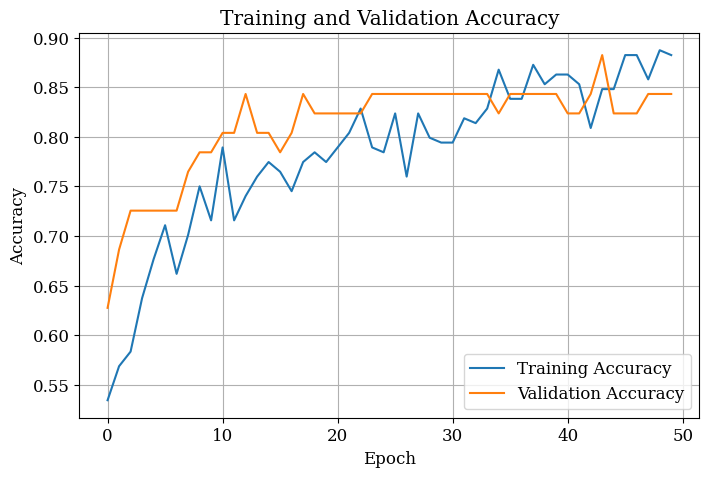

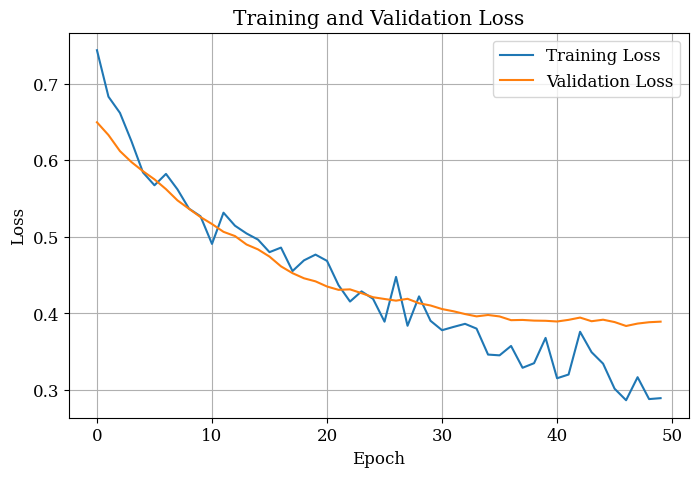

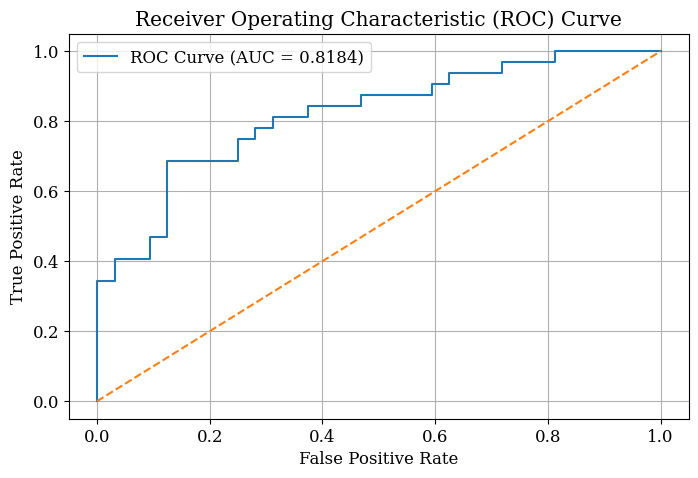

===== FNN Training and Evaluation Completed Successfully =====


In [12]:
# -------------------------------
# Evaluate the model on test data
# -------------------------------
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("\n===== Test Set Performance =====")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# -------------------------------
# Predict probabilities and classes
# -------------------------------
# Predict probabilities (values between 0 and 1)
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities to class labels using threshold 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# Flatten arrays for sklearn metrics
y_pred_prob = y_pred_prob.ravel()
y_pred = y_pred.ravel()

# -------------------------------
# Calculate evaluation metrics
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n===== Evaluation Metrics =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

print("\n===== Confusion Matrix =====")
print(cm)

# Optional: display confusion matrix in readable form
cm_df = pd.DataFrame(
    cm,
    index=['Actual 0 (No Gallstone)', 'Actual 1 (Gallstone)'],
    columns=['Predicted 0', 'Predicted 1']
)

print("\nConfusion Matrix as Table:")
display(cm_df)

# -------------------------------
# Classification Report
# -------------------------------
print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred, digits=4))

# -------------------------------
# Plot Training and Validation Accuracy
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot Training and Validation Loss
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot ROC Curve
# -------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 16. Final message
# -------------------------------
print("===== FNN Training and Evaluation Completed Successfully =====")

# **Convolutional Neural Network (CNN)**

In [14]:
# ============================================================
# 1D Convolutional Neural Network (CNN) for Gallstone Classification
# ============================================================
# Goal:
# Build, train, and evaluate a 1D CNN model for binary classification
# using the Gallstone dataset.
#
# Note:
# Since this is tabular data (not image data), we use Conv1D
# instead of a 2D CNN.
# ============================================================

# -------------------------------
# Import required libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# -------------------------------
# Convert DataFrame to NumPy arrays if needed
# -------------------------------
# This ensures compatibility with TensorFlow/Keras.
X_train_array = np.array(X_train_scaled)
X_test_array = np.array(X_test_scaled)
y_train_array = np.array(y_train)
y_test_array = np.array(y_test)

print("Original training shape:", X_train_array.shape)
print("Original testing shape :", X_test_array.shape)

# -------------------------------
# Reshape data for Conv1D
# -------------------------------
# Conv1D expects input in 3D format:
# (samples, timesteps/features, channels)

# Here:
# - samples = number of rows
# - timesteps/features = number of columns/features
# - channels = 1 (since each feature is treated as a single channel)
X_train_cnn = X_train_array.reshape(X_train_array.shape[0], X_train_array.shape[1], 1)
X_test_cnn = X_test_array.reshape(X_test_array.shape[0], X_test_array.shape[1], 1)

print("\nReshaped training shape for CNN:", X_train_cnn.shape)
print("Reshaped testing shape for CNN :", X_test_cnn.shape)

# -------------------------------
# Build the 1D CNN model
# -------------------------------
# Architecture:
# - Conv1D layer to learn local feature patterns
# - MaxPooling1D to reduce feature map size
# - Flatten to convert to 1D vector
# - Dense hidden layer
# - Output layer with sigmoid for binary classification

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=16, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(16, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# -------------------------------
# Compile the CNN model
# -------------------------------
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# Display model summary
# -------------------------------
print("\n===== CNN Model Summary =====")
cnn_model.summary()

# -------------------------------
# Define early stopping
# -------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# -------------------------------
# Train the CNN model
# -------------------------------
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_array,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Original training shape: (255, 38)
Original testing shape : (64, 38)

Reshaped training shape for CNN: (255, 38, 1)
Reshaped testing shape for CNN : (64, 38, 1)

===== CNN Model Summary =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 36, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 18, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 16, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 8, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,761 (14.69 KB)

 Trainable params: 3,761 (14.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5000 - loss: 0.7019 - val_accuracy: 0.4706 - val_loss: 0.6950
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4951 - loss: 0.6920 - val_accuracy: 0.4510 - val_loss: 0.6910
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5490 - loss: 0.6749 - val_accuracy: 0.5882 - val_loss: 0.6788
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6127 - loss: 0.6620 - val_accuracy: 0.6078 - val_loss: 0.6738
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6127 - loss: 0.6605 - val_accuracy: 0.5882 - val_loss: 0.6710
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5588 - loss: 0.6594 - val_accuracy: 0.6863 - val_loss: 0.6614
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6618 - loss: 0.6379 - val_accuracy: 0.6275 - val_loss: 0.6555
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6667 - loss: 0.6371 - val_accuracy: 0.6863 - v

## **Evalaution Metrics**


===== CNN Test Set Performance =====
Test Loss     : 0.6443
Test Accuracy : 0.6719
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

===== CNN Evaluation Metrics =====
Accuracy  : 0.6719
Precision : 0.7391
Recall    : 0.5312
F1-Score  : 0.6182
ROC-AUC   : 0.7559

===== CNN Confusion Matrix =====
[[26  6]
 [15 17]]

Confusion Matrix as Table:


,Predicted 0,Predicted 1
Actual 0 (No Gallstone),26,6
Actual 1 (Gallstone),15,17



===== CNN Classification Report =====
              precision    recall  f1-score   support

           0     0.6341    0.8125    0.7123        32
           1     0.7391    0.5312    0.6182        32

    accuracy                         0.6719        64
   macro avg     0.6866    0.6719    0.6653        64
weighted avg     0.6866    0.6719    0.6653        64



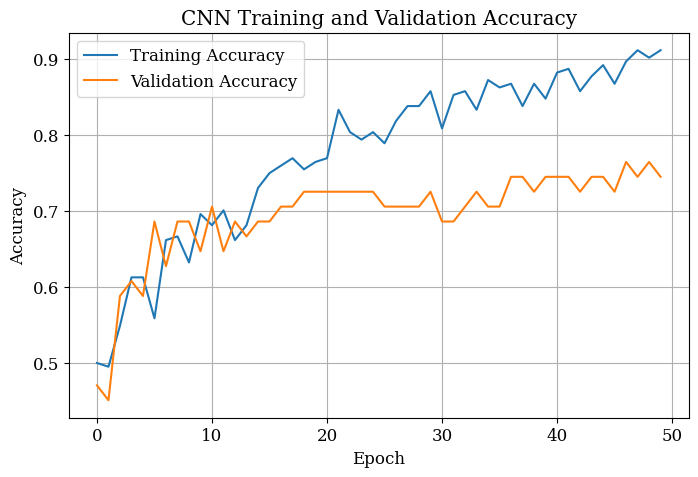

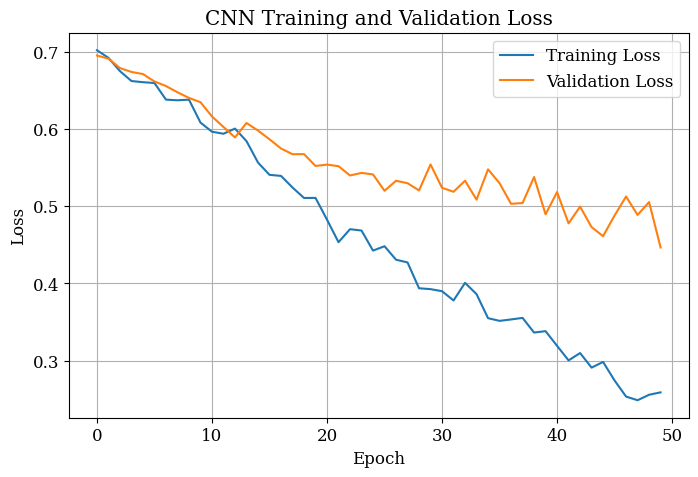

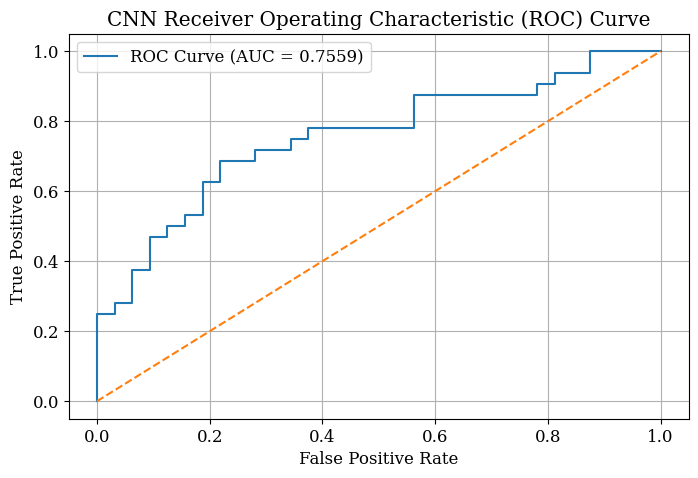

===== CNN Training and Evaluation Completed Successfully =====


In [15]:
# -------------------------------
# Evaluate the model on test data
# -------------------------------
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_cnn, y_test_array, verbose=0)

print("\n===== CNN Test Set Performance =====")
print(f"Test Loss     : {cnn_test_loss:.4f}")
print(f"Test Accuracy : {cnn_test_accuracy:.4f}")

# -------------------------------
# Predict probabilities and class labels
# -------------------------------
y_pred_prob_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int)

# Flatten arrays for sklearn metrics
y_pred_prob_cnn = y_pred_prob_cnn.ravel()
y_pred_cnn = y_pred_cnn.ravel()

# -------------------------------
# Calculate evaluation metrics
# -------------------------------
cnn_accuracy = accuracy_score(y_test_array, y_pred_cnn)
cnn_precision = precision_score(y_test_array, y_pred_cnn)
cnn_recall = recall_score(y_test_array, y_pred_cnn)
cnn_f1 = f1_score(y_test_array, y_pred_cnn)
cnn_roc_auc = roc_auc_score(y_test_array, y_pred_prob_cnn)

print("\n===== CNN Evaluation Metrics =====")
print(f"Accuracy  : {cnn_accuracy:.4f}")
print(f"Precision : {cnn_precision:.4f}")
print(f"Recall    : {cnn_recall:.4f}")
print(f"F1-Score  : {cnn_f1:.4f}")
print(f"ROC-AUC   : {cnn_roc_auc:.4f}")

# -------------------------------
# Confusion Matrix
# -------------------------------
cnn_cm = confusion_matrix(y_test_array, y_pred_cnn)

print("\n===== CNN Confusion Matrix =====")
print(cnn_cm)

cnn_cm_df = pd.DataFrame(
    cnn_cm,
    index=['Actual 0 (No Gallstone)', 'Actual 1 (Gallstone)'],
    columns=['Predicted 0', 'Predicted 1']
)

print("\nConfusion Matrix as Table:")
display(cnn_cm_df)

# -------------------------------
# Classification Report
# -------------------------------
print("\n===== CNN Classification Report =====")
print(classification_report(y_test_array, y_pred_cnn, digits=4))

# -------------------------------
# Plot Training and Validation Accuracy
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot Training and Validation Loss
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot ROC Curve
# -------------------------------
fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(y_test_array, y_pred_prob_cnn)

plt.figure(figsize=(8, 5))
plt.plot(fpr_cnn, tpr_cnn, label=f'ROC Curve (AUC = {cnn_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('CNN Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Final message
# -------------------------------
print("===== CNN Training and Evaluation Completed Successfully =====")

# **Radial Basis Function Network (RBFN)**

In [18]:
# ============================================================
# Radial Basis Function Network (RBFN) for Gallstone Classification
# ============================================================
# Goal:
# Build, train, and evaluate an RBFN model for binary classification
# using the Gallstone dataset.

# Idea:
# 1. Use K-Means clustering to determine RBF centers
# 2. Transform input data into radial basis activations
# 3. Train a dense output layer for binary classification
# ============================================================

# -------------------------------
# Import required libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# -------------------------------
# Convert training and testing data to NumPy arrays
# -------------------------------
X_train_rbfn = np.array(X_train_scaled)
X_test_rbfn = np.array(X_test_scaled)
y_train_rbfn = np.array(y_train)
y_test_rbfn = np.array(y_test)

print("Training feature shape :", X_train_rbfn.shape)
print("Testing feature shape  :", X_test_rbfn.shape)
print("Training label shape   :", y_train_rbfn.shape)
print("Testing label shape    :", y_test_rbfn.shape)

# -------------------------------
# Define the Gaussian RBF function
# -------------------------------
# Formula:
# phi(x, c) = exp( -beta * ||x - c||^2 )

# where:
# - x = input sample
# - c = center
# - beta controls the width of the Gaussian
def gaussian_rbf(X, centers, beta):
    """
    Compute Gaussian RBF activations.

    Parameters:
    X       : Input data of shape (n_samples, n_features)
    centers : RBF centers of shape (n_centers, n_features)
    beta    : Spread parameter for Gaussian RBF

    Returns:
    RBF activation matrix of shape (n_samples, n_centers)
    """
    X = np.array(X)
    centers = np.array(centers)

    # Compute squared Euclidean distance from every sample to every center
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    squared_dist = np.sum(diff ** 2, axis=2)

    # Apply Gaussian radial basis function
    return np.exp(-beta * squared_dist)

# -------------------------------
# 4. Select number of RBF centers
# -------------------------------
# This is a tunable hyperparameter.
# For a small dataset, 10 to 30 centers is a reasonable start.
n_centers = 20

# -------------------------------
# Use K-Means to find RBF centers
# -------------------------------
# K-Means finds representative cluster centers from training data.
kmeans = KMeans(n_clusters=n_centers, random_state=42, n_init=10)
kmeans.fit(X_train_rbfn)

centers = kmeans.cluster_centers_

print("\nNumber of RBF centers:", len(centers))
print("Shape of centers:", centers.shape)

# -------------------------------
# Compute beta (spread parameter)
# -------------------------------
# A common practical choice:
# beta = 1 / (2 * sigma^2)

# We estimate sigma from the average pairwise distance between centers.
from scipy.spatial.distance import cdist

center_distances = cdist(centers, centers, metric='euclidean')
max_distance = np.max(center_distances)

sigma = max_distance / np.sqrt(2 * n_centers)
beta = 1 / (2 * sigma ** 2)

print("\nEstimated sigma:", sigma)
print("Computed beta   :", beta)

# -------------------------------
# Transform original features into RBF features
# -------------------------------
# Each input sample is now represented by its distances
# to the learned RBF centers.
X_train_rbf_features = gaussian_rbf(X_train_rbfn, centers, beta)
X_test_rbf_features = gaussian_rbf(X_test_rbfn, centers, beta)

print("\nShape of transformed RBF training data:", X_train_rbf_features.shape)
print("Shape of transformed RBF testing data :", X_test_rbf_features.shape)

# -------------------------------
# Build the output classification network
# -------------------------------
# After RBF transformation, we use a small dense network.
# This acts as the output layer of the RBFN.
rbfn_model = Sequential([
    Input(shape=(n_centers,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# -------------------------------
# Compile the RBFN model
# -------------------------------
rbfn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# Display model summary
# -------------------------------
print("\n===== RBFN Model Summary =====")
rbfn_model.summary()

# -------------------------------
# Train the model
# -------------------------------
history_rbfn = rbfn_model.fit(
    X_train_rbf_features,
    y_train_rbfn,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Training feature shape : (255, 38)
Testing feature shape  : (64, 38)
Training label shape   : (255,)
Testing label shape    : (64,)

Number of RBF centers: 20
Shape of centers: (20, 38)

Estimated sigma: 3.250158582218895
Computed beta   : 0.047332658844235355

Shape of transformed RBF training data: (255, 20)
Shape of transformed RBF testing data : (64, 20)

===== RBFN Model Summary =====


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4951 - loss: 0.6953 - val_accuracy: 0.5294 - val_loss: 0.6938
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5049 - loss: 0.6932 - val_accuracy: 0.5294 - val_loss: 0.6914
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5147 - loss: 0.6912 - val_accuracy: 0.5490 - val_loss: 0.6915
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5735 - loss: 0.6898 - val_accuracy: 0.5490 - val_loss: 0.6903
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5686 - loss: 0.6884 - val_accuracy: 0.5490 - val_loss: 0.6888
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5637 - loss: 0.6872 - val_accuracy: 0.5490 - val_loss: 0.6876
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5735 - loss: 0.6861 - val_accuracy: 0.5686 - val_loss: 0.6872
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5784 - loss: 0.6849 - val_accuracy: 0.5686 - val_loss

## **Evalaution Metrics**


===== RBFN Test Set Performance =====
Test Loss     : 0.6492
Test Accuracy : 0.5781
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

===== RBFN Evaluation Metrics =====
Accuracy  : 0.5781
Precision : 0.5714
Recall    : 0.6250
F1-Score  : 0.5970
ROC-AUC   : 0.6855

===== RBFN Confusion Matrix =====
[[17 15]
 [12 20]]

Confusion Matrix as Table:


,Predicted 0,Predicted 1
Actual 0 (No Gallstone),17,15
Actual 1 (Gallstone),12,20



===== RBFN Classification Report =====
              precision    recall  f1-score   support

           0     0.5862    0.5312    0.5574        32
           1     0.5714    0.6250    0.5970        32

    accuracy                         0.5781        64
   macro avg     0.5788    0.5781    0.5772        64
weighted avg     0.5788    0.5781    0.5772        64



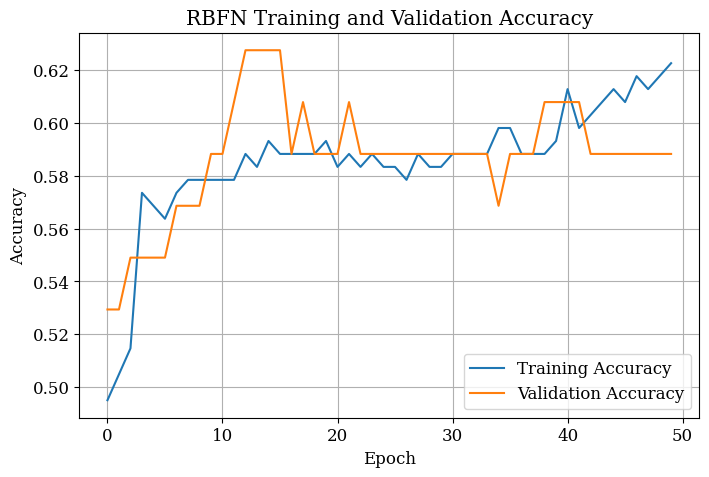

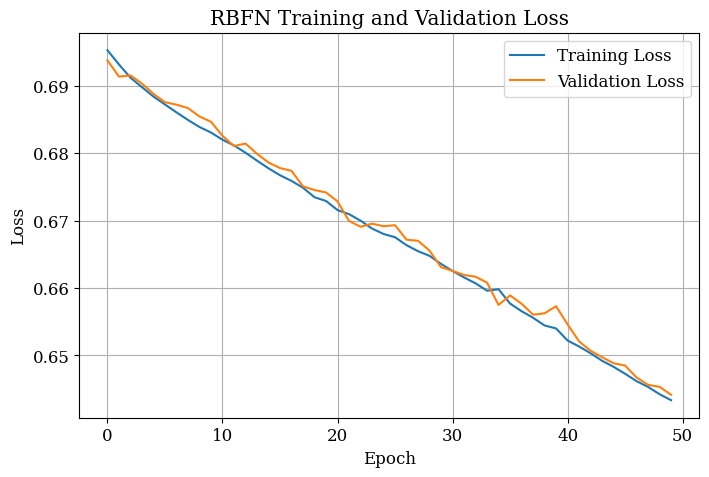

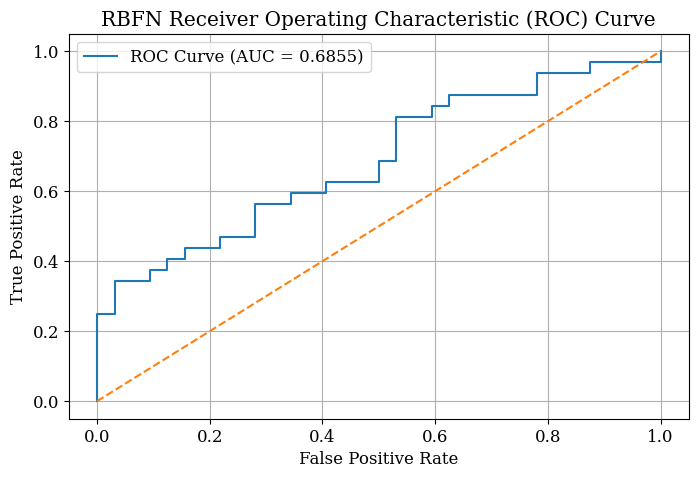

===== RBFN Training and Evaluation Completed Successfully =====


In [19]:
# -------------------------------
# Evaluate the model on test data
# -------------------------------
rbfn_test_loss, rbfn_test_accuracy = rbfn_model.evaluate(X_test_rbf_features, y_test_rbfn, verbose=0)

print("\n===== RBFN Test Set Performance =====")
print(f"Test Loss     : {rbfn_test_loss:.4f}")
print(f"Test Accuracy : {rbfn_test_accuracy:.4f}")

# -------------------------------
# Predict probabilities and classes
# -------------------------------
y_pred_prob_rbfn = rbfn_model.predict(X_test_rbf_features)
y_pred_rbfn = (y_pred_prob_rbfn > 0.5).astype(int)

# Flatten arrays for metric calculations
y_pred_prob_rbfn = y_pred_prob_rbfn.ravel()
y_pred_rbfn = y_pred_rbfn.ravel()

# -------------------------------
# Calculate evaluation metrics
# -------------------------------
rbfn_accuracy = accuracy_score(y_test_rbfn, y_pred_rbfn)
rbfn_precision = precision_score(y_test_rbfn, y_pred_rbfn)
rbfn_recall = recall_score(y_test_rbfn, y_pred_rbfn)
rbfn_f1 = f1_score(y_test_rbfn, y_pred_rbfn)
rbfn_roc_auc = roc_auc_score(y_test_rbfn, y_pred_prob_rbfn)

print("\n===== RBFN Evaluation Metrics =====")
print(f"Accuracy  : {rbfn_accuracy:.4f}")
print(f"Precision : {rbfn_precision:.4f}")
print(f"Recall    : {rbfn_recall:.4f}")
print(f"F1-Score  : {rbfn_f1:.4f}")
print(f"ROC-AUC   : {rbfn_roc_auc:.4f}")

# -------------------------------
# Confusion Matrix
# -------------------------------
rbfn_cm = confusion_matrix(y_test_rbfn, y_pred_rbfn)

print("\n===== RBFN Confusion Matrix =====")
print(rbfn_cm)

rbfn_cm_df = pd.DataFrame(
    rbfn_cm,
    index=['Actual 0 (No Gallstone)', 'Actual 1 (Gallstone)'],
    columns=['Predicted 0', 'Predicted 1']
)

print("\nConfusion Matrix as Table:")
display(rbfn_cm_df)

# -------------------------------
# Classification Report
# -------------------------------
print("\n===== RBFN Classification Report =====")
print(classification_report(y_test_rbfn, y_pred_rbfn, digits=4))

# -------------------------------
# Plot Training and Validation Accuracy
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_rbfn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rbfn.history['val_accuracy'], label='Validation Accuracy')
plt.title('RBFN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot Training and Validation Loss
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_rbfn.history['loss'], label='Training Loss')
plt.plot(history_rbfn.history['val_loss'], label='Validation Loss')
plt.title('RBFN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot ROC Curve
# -------------------------------
fpr_rbfn, tpr_rbfn, thresholds_rbfn = roc_curve(y_test_rbfn, y_pred_prob_rbfn)

plt.figure(figsize=(8, 5))
plt.plot(fpr_rbfn, tpr_rbfn, label=f'ROC Curve (AUC = {rbfn_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('RBFN Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Final message
# -------------------------------
print("===== RBFN Training and Evaluation Completed Successfully =====")

# **Recurrent Neural Network (RNN)**

In [21]:
# ============================================================
# Recurrent Neural Network (RNN) for Gallstone Classification
# ============================================================
# Goal:
# Build, train, and evaluate an RNN model for binary classification
# using the Gallstone dataset.
#
# Note:
# This dataset is tabular, not sequential. However, to demonstrate
# the RNN architecture, we reshape the feature vector of each sample
# as a sequence of timesteps.
# ============================================================

# -------------------------------
# Import required libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# -------------------------------
# Convert data into NumPy arrays
# -------------------------------
X_train_rnn = np.array(X_train_scaled)
X_test_rnn = np.array(X_test_scaled)
y_train_rnn = np.array(y_train)
y_test_rnn = np.array(y_test)

print("Original training shape:", X_train_rnn.shape)
print("Original testing shape :", X_test_rnn.shape)

# -------------------------------
# 3. Reshape data for RNN input
# -------------------------------
# RNN expects 3D input:
# (samples, timesteps, features_per_timestep)

# Here:
# - each original feature is treated as one timestep
# - each timestep contains 1 value

# So shape becomes:
# (number_of_samples, number_of_features, 1)
X_train_rnn = X_train_rnn.reshape(X_train_rnn.shape[0], X_train_rnn.shape[1], 1)
X_test_rnn = X_test_rnn.reshape(X_test_rnn.shape[0], X_test_rnn.shape[1], 1)

print("\nReshaped training shape for RNN:", X_train_rnn.shape)
print("Reshaped testing shape for RNN :", X_test_rnn.shape)

# -------------------------------
# Build the RNN model
# -------------------------------
# Architecture:
# - SimpleRNN layer to capture sequential dependencies
# - Dropout to reduce overfitting
# - Dense hidden layer
# - Output layer with sigmoid for binary classification

rnn_model = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(X_train_rnn.shape[1], 1), return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# -------------------------------
# Compile the model
# -------------------------------
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# Display model summary
# -------------------------------
print("\n===== RNN Model Summary =====")
rnn_model.summary()

# -------------------------------
# Define early stopping
# -------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# -------------------------------
# Train the RNN model
# -------------------------------
rnn_history = rnn_model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Original training shape: (255, 38)
Original testing shape : (64, 38)

Reshaped training shape for RNN: (255, 38, 1)
Reshaped testing shape for RNN : (64, 38, 1)

===== RNN Model Summary =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5833 - loss: 0.6948 - val_accuracy: 0.6471 - val_loss: 0.6366
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6078 - loss: 0.6558 - val_accuracy: 0.7451 - val_loss: 0.6070
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6716 - loss: 0.6122 - val_accuracy: 0.8039 - val_loss: 0.5877
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6814 - loss: 0.5908 - val_accuracy: 0.8235 - val_loss: 0.5665
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7304 - loss: 0.5715 - val_accuracy: 0.8039 - val_loss: 0.5500
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7304 - loss: 0.5488 - val_accuracy: 0.7843 - val_loss: 0.5512
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7059 - loss: 0.5525 - val_accuracy: 0.7843 - val_loss: 0.5504
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7451 - loss: 0.5459 - val_accuracy: 0.7451 - v

## **Evalaution Metrics**


===== RNN Test Set Performance =====
Test Loss     : 0.4373
Test Accuracy : 0.8125
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 

===== RNN Evaluation Metrics =====
Accuracy  : 0.8125
Precision : 0.8333
Recall    : 0.7812
F1-Score  : 0.8065
ROC-AUC   : 0.8975

===== RNN Confusion Matrix =====
[[27  5]
 [ 7 25]]

Confusion Matrix as Table:


,Predicted 0,Predicted 1
Actual 0 (No Gallstone),27,5
Actual 1 (Gallstone),7,25



===== RNN Classification Report =====
              precision    recall  f1-score   support

           0     0.7941    0.8438    0.8182        32
           1     0.8333    0.7812    0.8065        32

    accuracy                         0.8125        64
   macro avg     0.8137    0.8125    0.8123        64
weighted avg     0.8137    0.8125    0.8123        64



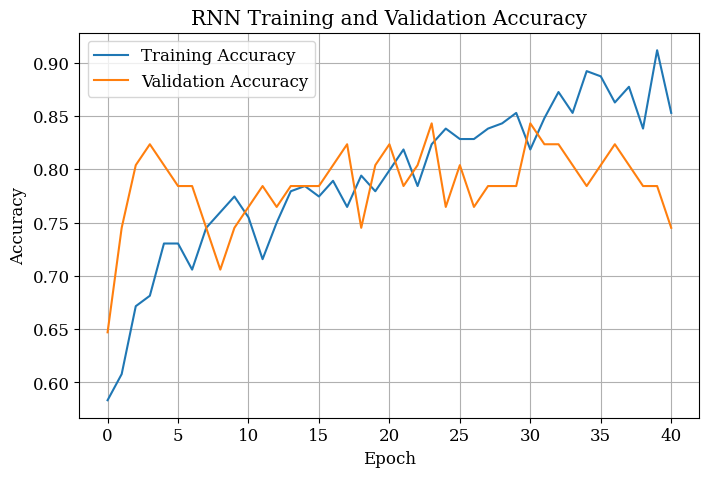

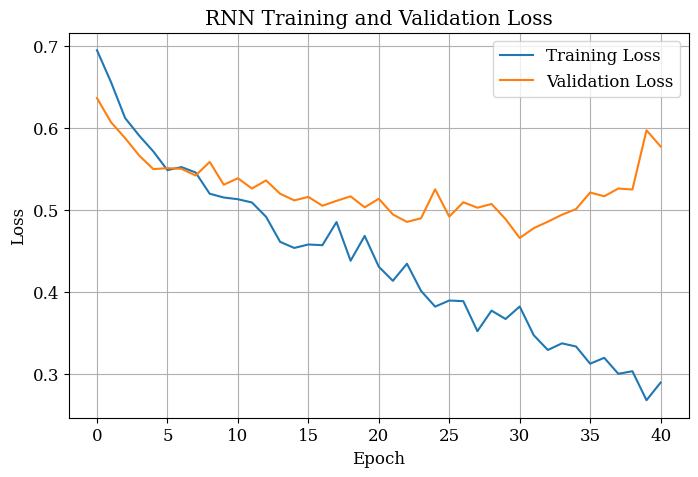

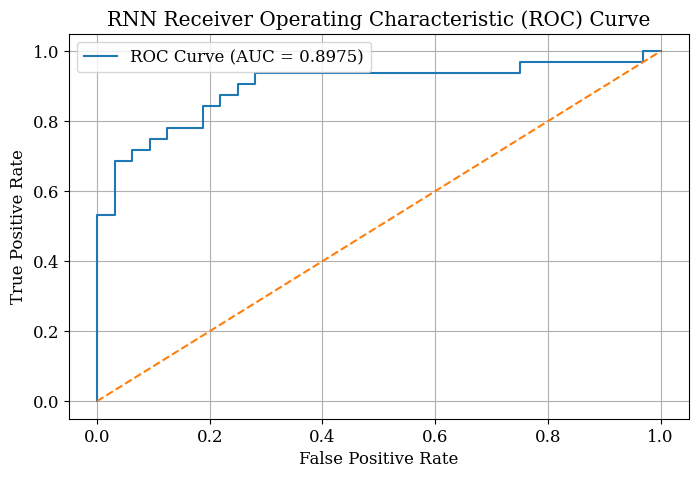

===== RNN Training and Evaluation Completed Successfully =====


In [22]:

# -------------------------------
# Evaluate the model on test data
# -------------------------------
rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(X_test_rnn, y_test_rnn, verbose=0)

print("\n===== RNN Test Set Performance =====")
print(f"Test Loss     : {rnn_test_loss:.4f}")
print(f"Test Accuracy : {rnn_test_accuracy:.4f}")

# -------------------------------
# Predict probabilities and classes
# -------------------------------
y_pred_prob_rnn = rnn_model.predict(X_test_rnn)
y_pred_rnn = (y_pred_prob_rnn > 0.5).astype(int)

# Flatten arrays for sklearn metrics
y_pred_prob_rnn = y_pred_prob_rnn.ravel()
y_pred_rnn = y_pred_rnn.ravel()

# -------------------------------
# Calculate evaluation metrics
# -------------------------------
rnn_accuracy = accuracy_score(y_test_rnn, y_pred_rnn)
rnn_precision = precision_score(y_test_rnn, y_pred_rnn)
rnn_recall = recall_score(y_test_rnn, y_pred_rnn)
rnn_f1 = f1_score(y_test_rnn, y_pred_rnn)
rnn_roc_auc = roc_auc_score(y_test_rnn, y_pred_prob_rnn)

print("\n===== RNN Evaluation Metrics =====")
print(f"Accuracy  : {rnn_accuracy:.4f}")
print(f"Precision : {rnn_precision:.4f}")
print(f"Recall    : {rnn_recall:.4f}")
print(f"F1-Score  : {rnn_f1:.4f}")
print(f"ROC-AUC   : {rnn_roc_auc:.4f}")

# -------------------------------
# Confusion Matrix
# -------------------------------
rnn_cm = confusion_matrix(y_test_rnn, y_pred_rnn)

print("\n===== RNN Confusion Matrix =====")
print(rnn_cm)

rnn_cm_df = pd.DataFrame(
    rnn_cm,
    index=['Actual 0 (No Gallstone)', 'Actual 1 (Gallstone)'],
    columns=['Predicted 0', 'Predicted 1']
)

print("\nConfusion Matrix as Table:")
display(rnn_cm_df)

# -------------------------------
# Classification Report
# -------------------------------
print("\n===== RNN Classification Report =====")
print(classification_report(y_test_rnn, y_pred_rnn, digits=4))

# -------------------------------
# Plot Training and Validation Accuracy
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(rnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot Training and Validation Loss
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(rnn_history.history['loss'], label='Training Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot ROC Curve
# -------------------------------
fpr_rnn, tpr_rnn, thresholds_rnn = roc_curve(y_test_rnn, y_pred_prob_rnn)

plt.figure(figsize=(8, 5))
plt.plot(fpr_rnn, tpr_rnn, label=f'ROC Curve (AUC = {rnn_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('RNN Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Final message
# -------------------------------
print("===== RNN Training and Evaluation Completed Successfully =====")

# **Thank You**